# Внутри часа: 15-минутные данные и ранний сигнал

Этап 6. Данные — `data/interim/spb_line1_15min.parquet` (`python -m src.clean_spb_15min`), часовые — `spb_line1_hourly.parquet`.
Расчёты — в `src/intrahour.py`; здесь только вызовы, графики `reports/figures/spb_16_*.png` и строка с цифрами под каждым.
Замороженная часовая модель не меняется: норма b4, опорные прогнозы и пороги берутся из неё как есть.

**Данные.** Февраль, май, июль и сентябрь 2026, 24 вестибюля (с Технологическим институтом, которого нет в часовом файле).
Исключены часы с любым флагом:
- флаги часового файла;
- `is_source_mismatch` — |Σ 4 слотов − час| > max(100; 20 %);
- `is_slot_closed` — частичное закрытие: слот ≤ max(2; 2 % медианы) при медиане слота ≥ 50.

**Профиль.**
- Доля четверти j — Σ y_j / Σ y_часа по обычным суткам.
- Тип дня — рабочий / суббота / воскресенье; праздник считается воскресеньем.
- Вокзалы: Девяткино, пл. Ленина, пл. Восстания, Балтийская.

**Ранний сигнал** (вариант A).
- Истина — часовой файл: R = y / b4, аномальный час — |R − 1| > p95 группы и периода суток (`anomaly_thresholds.csv`).
- Частичное отклонение: r_k = Σ_{j<k} y_j / (b4 · s_v · Σ_{j<k} p_j).
  - Профиль p — по прошлым суткам того же типа.
  - s_v — 15-минутный / часовой источник за 14 прошлых общих суток.
- Детектор: тревога на первом k, где |r_k − 1| > c_k · p95 и знак совпадает с истиной.
  c_k — максимум F1 на феврале + мае + июле.
- Сентябрь — проверка. Часовые результаты по нему уже известны (финальный тест этапа 5), поэтому он не чистая
  отложенная выборка.

Выводы — `docs/intrahour_findings.md`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

from src import config, eda, reference
from src import eda_spb as E
from src import intrahour as I

eda.style()
PCT = PercentFormatter(1.0, decimals=0)
HOURS = I.PROFILE_HOURS                       # 05 … 23, 00
WORK = E.WORK_HOURS                           # 06 … 23, 00
HPOS = {h: i for i, h in enumerate(WORK)}
BLUE, ORANGE = eda.SERIES[0], eda.SERIES[1]
RAMP4 = ["#86b6ef", "#3987e5", "#256abf", "#0d366b"]   # упорядоченная шкала (месяцы), dataviz: синий 250 … 700
KIND_COLORS = {"вокзалы": BLUE, "остальные": ORANGE}
pp = lambda x, nd=1: f"{x:.{nd}%}".replace(".", ",")
num = lambda x, nd=0: f"{x:,.{nd}f}".replace(",", " ").replace(".", ",")
ppt = lambda x, nd=1: f"{x * 100:.{nd}f}".replace(".", ",")

ves15 = reference.load_vestibules_15min()
NAME = ves15.set_index("vestibule_id").raw_name_15min
res = I.run()
I.save(res)
sig = res.signal
sel, sep = I.split_periods(sig)
print(f"Часов «вестибюль × час»: {num(len(res.hours))}; в оценке раннего сигнала — {num(len(sel))} (фев + май + июль) "
      f"и {num(len(sep))} (сентябрь); аномальных: {pp(sel.anom.mean())} и {pp(sep.anom.mean())}.")

Часов «вестибюль × час»: 69 120; в оценке раннего сигнала — 32 143 (фев + май + июль) и 11 833 (сентябрь); аномальных: 6,7% и 20,2%.


## 1. Сверка с часовыми данными

Подробный отчёт — `logs/clean_spb_15min.log`, сводки — `reports/intrahour/reconciliation_summary.csv`,
выбросы — `source_mismatch.csv`, частичные закрытия — `slot_closures.csv`.

In [2]:
summ = pd.read_csv(I.OUT / "reconciliation_summary.csv")
line = summ[summ.slice == "вся линия"].iloc[0]
by = lambda s: summ[summ.slice == s].set_index("key")
show = by("месяц")[["n_hours", "exact_share", "excess", "median_rel", "within_1pct", "within_5pct", "mismatch_hours"]]
display(show.style.format({"exact_share": "{:.1%}", "excess": "{:+.2%}", "median_rel": "{:+.2%}", "within_1pct": "{:.1%}",
                           "within_5pct": "{:.1%}"}))
v = by("вестибюль").excess
h = by("час").excess
print(f"Сумма 4 интервалов = часу точно в {pp(line.exact_share)} часов работы метро; 15-минутный источник выше на "
      f"{pp(line.excess, 2)} (по месяцам {pp(show.excess.min(), 2)}…{pp(show.excess.max(), 2)}), по вестибюлям — "
      f"от {pp(v.min(), 1)} ({NAME[v.idxmin()]}) до {pp(v.max(), 1)} ({NAME[v.idxmax()]}); по часам — от {pp(h.min(), 1)} "
      f"(00 ч) до {pp(h.max(), 1)} ({int(h.idxmax()):02d} ч).")
sc = pd.read_csv(I.OUT / "slot_closures.csv")
mm = pd.read_csv(I.OUT / "source_mismatch.csv")
print(f"Выбросов (is_source_mismatch): {len(mm)} ч; частичных закрытий (is_slot_closed): {len(sc)} ч — "
      + ", ".join(f"{NAME[k]} {n}" for k, n in sc.vestibule_id.value_counts().items()) + ".")

,n_hours,exact_share,excess,median_rel,within_1pct,within_5pct,mismatch_hours
key,,,,,,,
2,12712,1.8%,+1.15%,+1.52%,32.5%,83.5%,9
5,14068,1.7%,+1.17%,+1.43%,34.3%,85.1%,9
7,14074,1.7%,+1.14%,+1.40%,34.5%,85.5%,3
9,13166,1.8%,+1.13%,+1.40%,35.3%,84.4%,8


Сумма 4 интервалов = часу точно в 1,7% часов работы метро; 15-минутный источник выше на 1,15% (по месяцам 1,13%…1,17%), по вестибюлям — от 0,4% (Пл. Восстания-2) до 4,1% (Ленинский пр.-2); по часам — от -2,5% (00 ч) до 4,3% (23 ч).
Выбросов (is_source_mismatch): 31 ч; частичных закрытий (is_slot_closed): 61 ч — Балтийская 25, Нарвская 23, Пл. Мужества 4, Пр.Ветеранов-2 4, Политехническая 2, Пл. Восстания-1 2, Академическая 1.


## 2. Профиль внутри часа

### Карта профиля

Доля каждой четверти часа минус 1/4 по вестибюлям, рабочие дни, все 4 месяца.

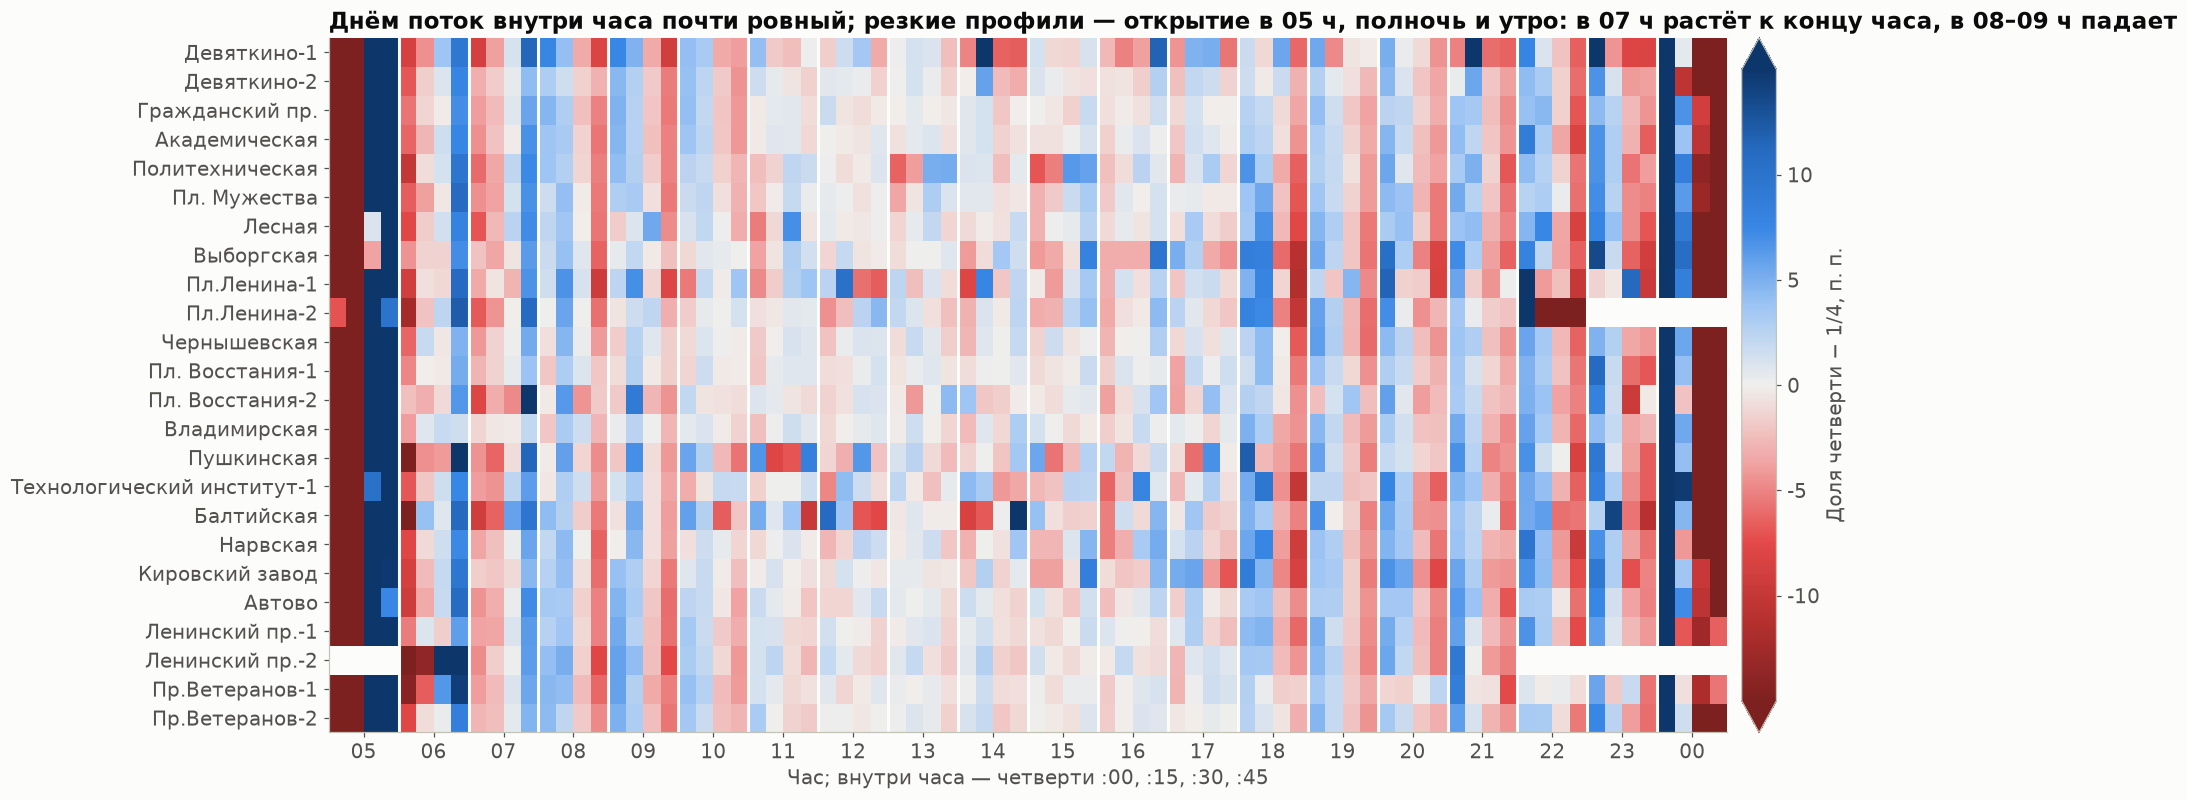

Неравномерность U (какую долю часа пришлось бы переложить до ровного профиля), взвешено по потоку: 07–22 ч рабочего дня — 5,8%; 05 ч — 47,9% (метро открывается в ~05:30), 00 ч — 45,7% (поток к 00:30 почти кончается). Утро рабочего дня: в 07 ч последняя четверть 31,8%, в 08 ч первая — 28,3%, последняя — 19,7%.


In [3]:
cells = res.cells
order = ves15.vestibule_id.tolist()
cols = pd.MultiIndex.from_product([HOURS, range(4)])
wd = cells[cells.day3 == "рабочий"].set_index(["vestibule_id", "hour"])[I.PCOLS]
mat = np.full((len(order), len(cols)), np.nan)
for i, v in enumerate(order):
    for j, (hr, q) in enumerate(cols):
        if (v, hr) in wd.index:
            mat[i, j] = wd.loc[(v, hr), f"p{q}"] - 0.25
cmap = E.diverging_cmap().copy()
cmap.set_bad(eda.SURFACE)
fig, ax = plt.subplots(figsize=(17, 8.2))
im = ax.imshow(mat, aspect="auto", cmap=cmap, norm=TwoSlopeNorm(0, -0.15, 0.15), interpolation="nearest")
for j in range(1, len(HOURS)):
    ax.axvline(4 * j - 0.5, color=eda.SURFACE, linewidth=2)
ax.set_xticks([4 * j + 1.5 for j in range(len(HOURS))], [f"{h:02d}" for h in HOURS])
ax.set_yticks(range(len(order)), [NAME[v] for v in order])
ax.grid(False)
ax.set_xlabel("Час; внутри часа — четверти :00, :15, :30, :45")
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, extend="both")
cb.set_label("Доля четверти − 1/4, п. п.")
cb.ax.yaxis.set_major_formatter(lambda x, _: ppt(x, 0))
ax.set_title("Днём поток внутри часа почти ровный; резкие профили — открытие в 05 ч, полночь и утро: "
             "в 07 ч растёт к концу часа, в 08–09 ч падает", loc="left")
eda.save(fig, "spb_16_profile_heatmap")
plt.show()

w = lambda df, c: np.average(df[c], weights=df.total)
day = cells[cells.hour.isin(range(7, 23)) & (cells.day3 == "рабочий")]
h7 = cells[(cells.hour == 7) & (cells.day3 == "рабочий")]
h8 = cells[(cells.hour == 8) & (cells.day3 == "рабочий")]
print(f"Неравномерность U (какую долю часа пришлось бы переложить до ровного профиля), взвешено по потоку: 07–22 ч "
      f"рабочего дня — {pp(w(day, 'U'))}; 05 ч — {pp(w(cells[cells.hour == 5], 'U'))} (метро открывается в ~05:30), "
      f"00 ч — {pp(w(cells[cells.hour == 0], 'U'))} (поток к 00:30 почти кончается). Утро рабочего дня: в 07 ч последняя "
      f"четверть {pp(w(h7, 'p3'))}, в 08 ч первая — {pp(w(h8, 'p0'))}, последняя — {pp(w(h8, 'p3'))}.")

### Вокзалы против остальных

**U** — неравномерность профиля.

**φ** — сверхдисперсия: средний χ² дня против профиля ячейки, делённый на 3.
- φ = 1 — доли гуляют от дня к дню только из-за счётного шума.
- φ > 1 — сильнее: волны прибытия поездов, расписание, разовые события.

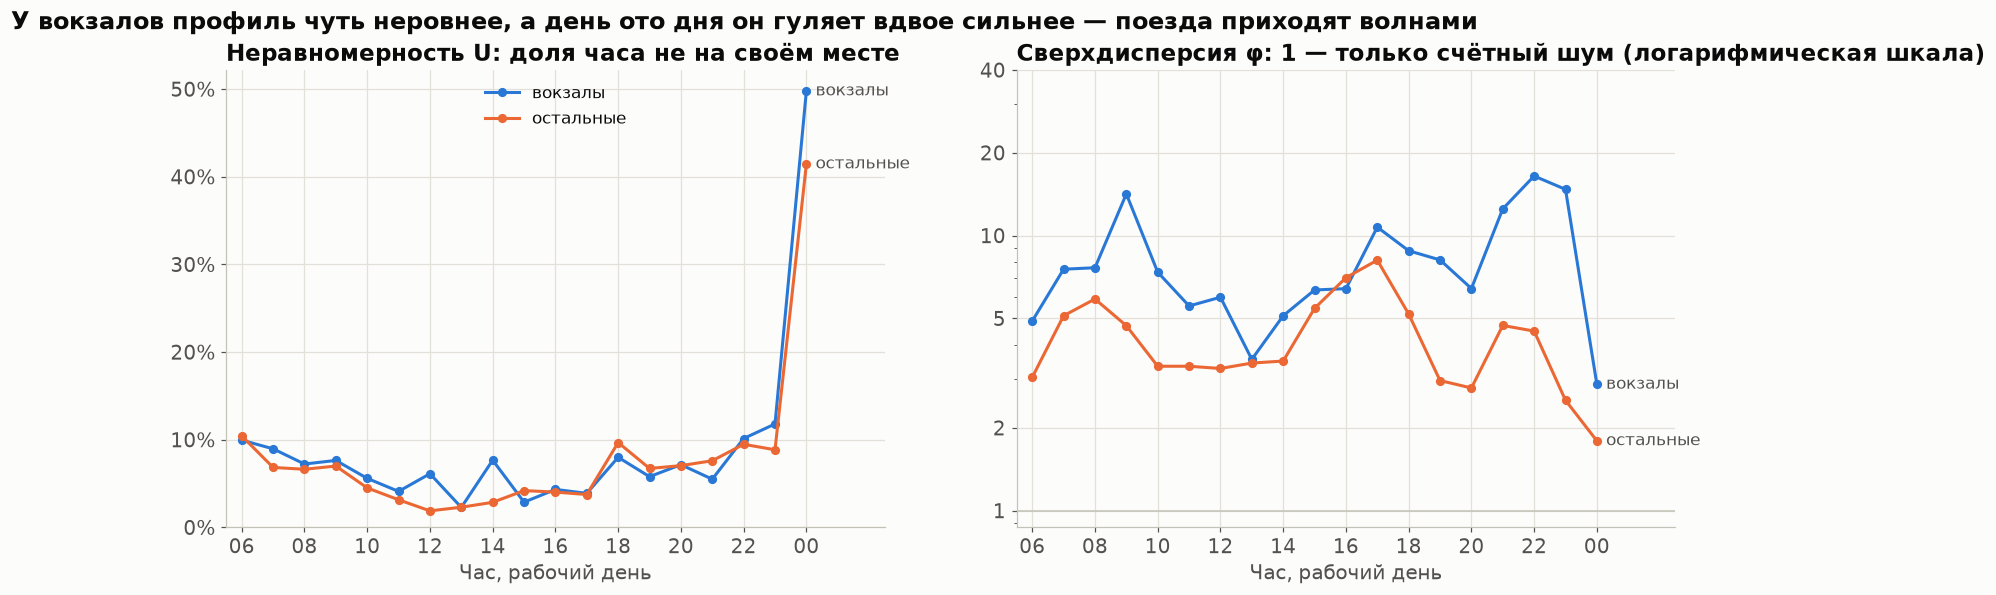

U               phi          
kind        вокзалы остальные вокзалы остальные
day3                                           
воскресенье   0.071     0.036   9.894     2.780
рабочий       0.065     0.059   8.315     4.900
суббота       0.060     0.035   8.729     3.693

Взвешено по потоку, часы 06–00: U вокзалов / остальных — рабочий 6,5% / 5,9%; суббота 6,0% / 3,5%; воскресенье 7,1% / 3,6%; φ — рабочий 8,3 / 4,9; суббота 8,7 / 3,7; воскресенье 9,9 / 2,8.


In [4]:
hubs = res.hubs[res.hubs.day3 == "рабочий"]
fig, axes = plt.subplots(1, 2, figsize=(17, 5.4))
for kind, color in KIND_COLORS.items():
    x = hubs[(hubs.kind == kind) & hubs.hour.isin(WORK)].set_index("hour").reindex(WORK)
    for ax, col in zip(axes, ("U", "phi")):
        ax.plot(range(len(WORK)), x[col].to_numpy(), color=color, marker="o", markersize=5, label=kind)
        ax.annotate(kind, (len(WORK) - 1, x[col].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                    va="center", color=eda.INK2, fontsize=11)
for ax in axes:
    ax.set_xticks(range(0, len(WORK), 2), [f"{h:02d}" for h in WORK[::2]])
    ax.set_xlabel("Час, рабочий день")
    ax.set_xlim(-0.5, len(WORK) + 1.5)
axes[0].yaxis.set_major_formatter(PCT)
axes[0].set_ylim(0, None)
axes[0].set_title("Неравномерность U: доля часа не на своём месте", loc="left")
axes[1].set_yscale("log")
axes[1].axhline(1, color=eda.AXIS, linewidth=1)
axes[1].set_yticks([1, 2, 5, 10, 20, 40], ["1", "2", "5", "10", "20", "40"])
axes[1].set_title("Сверхдисперсия φ: 1 — только счётный шум (логарифмическая шкала)", loc="left")
axes[0].legend(loc="upper center")
fig.suptitle("У вокзалов профиль чуть неровнее, а день ото дня он гуляет вдвое сильнее — поезда приходят волнами",
             x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "spb_16_nonuniformity")
plt.show()

c = res.cells.assign(kind=np.where(res.cells.hub, "вокзалы", "остальные"))
wavg = lambda g, col: np.average(g[col].dropna(), weights=g.loc[g[col].notna(), "total"])
tab = c[c.hour.isin(WORK)].groupby(["kind", "day3"]).apply(
    lambda g: pd.Series({"U": wavg(g, "U"), "phi": wavg(g, "phi")}), include_groups=False).unstack("kind")
display(tab.round(3))
print("Взвешено по потоку, часы 06–00: U вокзалов / остальных — " + "; ".join(
    f"{d} {pp(tab.loc[d, ('U', 'вокзалы')])} / {pp(tab.loc[d, ('U', 'остальные')])}" for d in I.DAY_TYPES3)
      + "; φ — " + "; ".join(f"{d} {num(tab.loc[d, ('phi', 'вокзалы')], 1)} / {num(tab.loc[d, ('phi', 'остальные')], 1)}"
                             for d in I.DAY_TYPES3) + ".")

### Стабильность между месяцами

Среднее ½Σ|p_m − p_m'| по парам месяцев сравнивается с тем, что дают перестановки суток между месяцами (200 перестановок
в каждой ячейке «вестибюль × тип дня × час»): если наблюдаемое расстояние не выше нулевого, профиль стабилен.

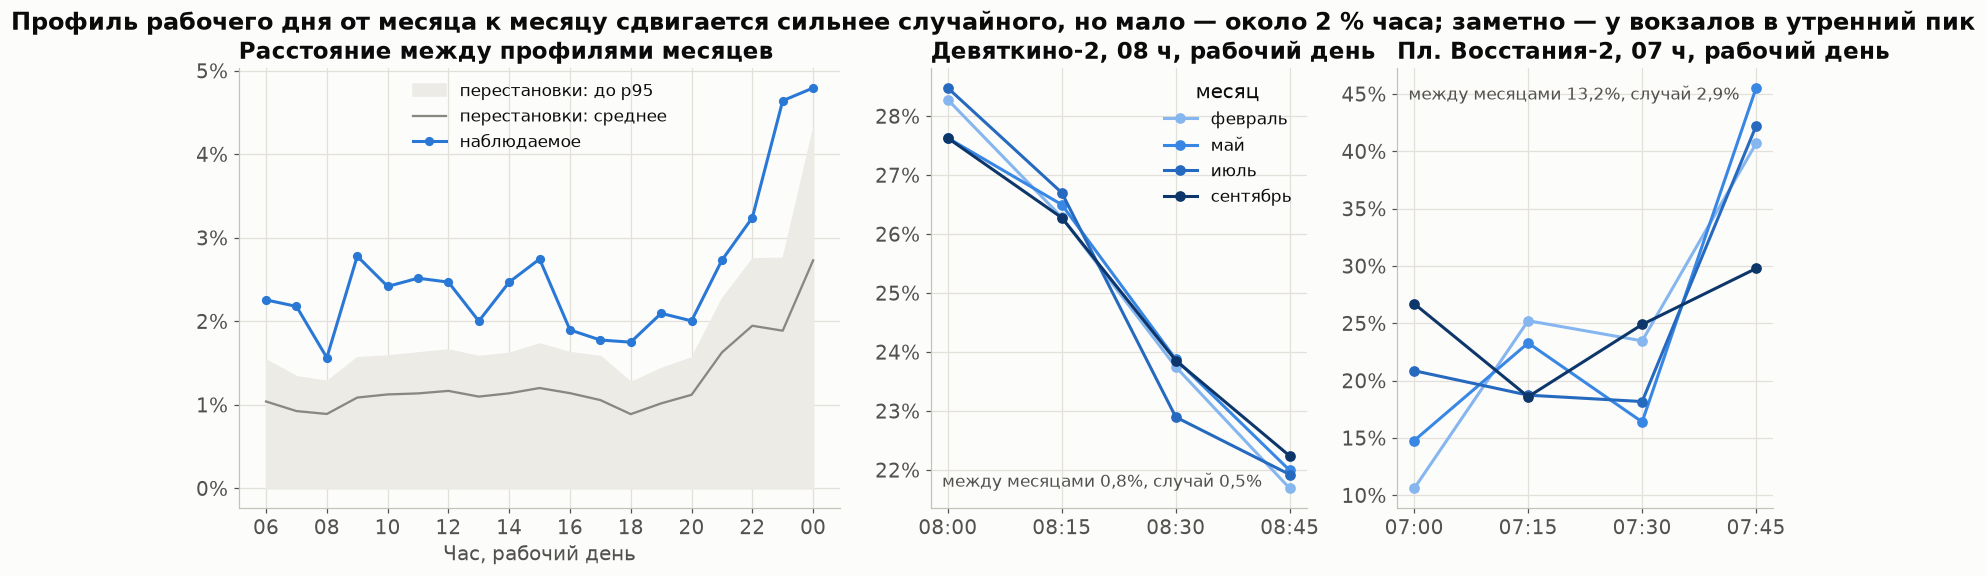

Расстояние между месяцами, взвешено по потоку (наблюдаемое / перестановки / доля потока в ячейках с p_BH < 0,05): рабочий 2,2% / 1,1% / 54%; суббота 3,7% / 3,0% / 15%; воскресенье 3,8% / 3,0% / 17%.


,name,day3,hour,n_days,d_obs,d_null,p_bh
812,Пушкинская,воскресенье,6,17,0.212,0.101,0.022
850,Пушкинская,суббота,6,16,0.186,0.103,0.039
520,Пл.Ленина-1,суббота,23,16,0.162,0.102,0.022
817,Пушкинская,воскресенье,11,17,0.148,0.073,0.022
714,Пл. Восстания-2,рабочий,7,80,0.132,0.029,0.022
713,Пл. Восстания-2,рабочий,6,80,0.132,0.040,0.022
859,Пушкинская,суббота,15,16,0.125,0.061,0.022
736,Пл. Восстания-2,суббота,9,16,0.122,0.063,0.022


In [5]:
st = res.stability
wd = st[st.day3 == "рабочий"]
agg = wd.groupby("hour").apply(lambda g: pd.Series({"obs": np.average(g.d_obs, weights=g.total),
                                                      "null": np.average(g.d_null, weights=g.total),
                                                      "p95": np.average(g.d_null_p95, weights=g.total)}),
                               include_groups=False).reindex(WORK)
mp = I.monthly_profiles(res.hours, ["vestibule_id", "day3", "hour"])
examples = [("devyatkino_2", 8, 0.04, "bottom"), ("vosstaniya_2", 7, 0.96, "top")]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), gridspec_kw={"width_ratios": [1.6, 1, 1]})
ax = axes[0]
x = np.arange(len(WORK))
ax.fill_between(x, 0, agg.p95, color="#ecebe6", label="перестановки: до p95")
ax.plot(x, agg.null, color=eda.MUTED, linewidth=1.5, label="перестановки: среднее")
ax.plot(x, agg.obs, color=BLUE, marker="o", markersize=5, label="наблюдаемое")
ax.set_xticks(x[::2], [f"{h:02d}" for h in WORK[::2]])
ax.yaxis.set_major_formatter(PCT)
ax.set_xlabel("Час, рабочий день")
ax.set_title("Расстояние между профилями месяцев", loc="left")
ax.legend(loc="upper center")
for ax, (v, hr, ty, va) in zip(axes[1:], examples):
    e = mp[(mp.vestibule_id == v) & (mp.day3 == "рабочий") & (mp.hour == hr)].sort_values("month")
    row = st[(st.vestibule_id == v) & (st.day3 == "рабочий") & (st.hour == hr)].iloc[0]
    for color, r in zip(RAMP4, e.itertuples()):
        ax.plot(range(4), [getattr(r, p) for p in I.PCOLS], color=color, marker="o", markersize=6,
                label=I.MONTH_RU[r.month])
    ax.set_xticks(range(4), [f"{hr:02d}:{m:02d}" for m in (0, 15, 30, 45)])
    ax.yaxis.set_major_formatter(PCT)
    ax.set_title(f"{NAME[v]}, {hr:02d} ч, рабочий день", loc="left")
    ax.text(0.03, ty, f"между месяцами {pp(row.d_obs)}, случай {pp(row.d_null)}", transform=ax.transAxes,
            va=va, fontsize=11, color=eda.INK2)
axes[1].legend(loc="upper right", title="месяц")
fig.suptitle("Профиль рабочего дня от месяца к месяцу сдвигается сильнее случайного, но мало — около 2 % часа; "
             "заметно — у вокзалов в утренний пик", x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "spb_16_stability")
plt.show()

tot = st.groupby("day3").apply(lambda g: pd.Series({"obs": np.average(g.d_obs, weights=g.total),
                                                    "null": np.average(g.d_null, weights=g.total),
                                                    "sig": np.average(g.p_bh < 0.05, weights=g.total)}),
                               include_groups=False)
print("Расстояние между месяцами, взвешено по потоку (наблюдаемое / перестановки / доля потока в ячейках с p_BH < 0,05): "
      + "; ".join(f"{d} {pp(tot.loc[d, 'obs'])} / {pp(tot.loc[d, 'null'])} / {pp(tot.loc[d, 'sig'], 0)}" for d in I.DAY_TYPES3)
      + ".")
top = st[st.p_bh < 0.05].sort_values("d_obs", ascending=False).head(8)
display(top.assign(name=top.vestibule_id.map(NAME))[["name", "day3", "hour", "n_days", "d_obs", "d_null", "p_bh"]].round(3))

### Таблица для симулятора

`data/reference/intrahour_profile.csv`:
- ключ — вестибюль или станция целиком (`vestibule_id = "*"`) × тип дня × час × четверть → доля;
- данные — все 4 месяца;
- ячейка с < 3 суток или < 200 входов заменяется профилем станции, затем группы, затем линии (колонка `source`).

In [6]:
sim = res.sim
cell = sim[sim.quarter == 0]
print(f"Строк: {num(len(sim))} ({num(len(cell))} ячеек × 4 четверти); вестибюлей {sim[sim.vestibule_id != '*'].vestibule_id.nunique()}, "
      f"станций {sim.station_id.nunique()}; подстановки у вестибюлей: "
      + ", ".join(f"{k} {v}" for k, v in cell[cell.vestibule_id != "*"].source.value_counts().items())
      + f"; с пометкой Технологического института: {(cell.note != '').sum()} ячеек.")
display(sim[(sim.station_id == "vosstaniya") & (sim.day_type == "рабочий") & sim.hour.isin([7, 8])].head(12))

Строк: 10 248 (2 562 ячеек × 4 четверти); вестибюлей 24, станций 19; подстановки у вестибюлей: вестибюль 1412, группа 6, станция 4; с пометкой Технологического института: 120 ячеек.


,station_id,vestibule_id,day_type,hour,quarter,share,n_days,source,note
4784,vosstaniya,vosstaniya_1,рабочий,7,0,0.221613,80,вестибюль,
4785,vosstaniya,vosstaniya_1,рабочий,7,1,0.236905,80,вестибюль,
4786,vosstaniya,vosstaniya_1,рабочий,7,2,0.253664,80,вестибюль,
4787,vosstaniya,vosstaniya_1,рабочий,7,3,0.287818,80,вестибюль,
4788,vosstaniya,vosstaniya_1,рабочий,8,0,0.230844,80,вестибюль,
4789,vosstaniya,vosstaniya_1,рабочий,8,1,0.280355,80,вестибюль,
4790,vosstaniya,vosstaniya_1,рабочий,8,2,0.258222,80,вестибюль,
4791,vosstaniya,vosstaniya_1,рабочий,8,3,0.230578,80,вестибюль,
5024,vosstaniya,vosstaniya_2,рабочий,7,0,0.171385,80,вестибюль,
5025,vosstaniya,vosstaniya_2,рабочий,7,1,0.217927,80,вестибюль,


## 3. Ранний сигнал

### Насколько часть часа предсказывает весь час

ŷ = b4 · r_k — это экстраполяция наблюдённой части часа по профилю. Опорные точки минуты 0 — то, что есть к началу часа
по часовым данным: норма, «b × r(t)», лучший бейзлайн «b × уровень × r(t)» и прогноз t+1 замороженной модели
(есть в кэше только для мая и июля). WAPE — к часовому файлу, ДИ — бутстреп по дням.

In [7]:
fc = res.forecast
show = fc.pivot_table(index=["minute", "label"], columns="period", values=["wape", "spearman"], sort=False)
display(show.style.format("{:.3f}"))
dl = res.deltas
REF = {"f_level_r": "«b × уровень × r(t)»", "f_model": "модели t+1 (май, июль, те же строки)"}
display(dl.assign(ref=dl.b.map(REF)).round(4))
for b, g in dl.groupby("b", sort=False):
    print(f"ΔWAPE экстраполяции против {REF[b]} (минус — экстраполяция точнее): " + "; ".join(
        f"{15 * int(r.a[1:])} мин, {r.period}: {ppt(r.delta_wape, 2)} п. п. [{ppt(r.lo, 2)}; {ppt(r.hi, 2)}]"
        for r in g.itertuples()))

,period,a,b,n,wape_a,wape_b,delta_wape,lo,hi,ref
0,сентябрь,r1,f_level_r,11833,0.0750,0.0863,-0.0114,-0.0205,-0.0033,«b × уровень × r(t)»
1,фев + май + июль,r1,f_level_r,32143,0.0794,0.0605,0.0189,0.0167,0.0210,«b × уровень × r(t)»
2,сентябрь,r2,f_level_r,11833,0.0437,0.0863,-0.0426,-0.0517,-0.0341,«b × уровень × r(t)»
3,фев + май + июль,r2,f_level_r,32143,0.0449,0.0605,-0.0155,-0.0177,-0.0135,«b × уровень × r(t)»
4,сентябрь,r3,f_level_r,11833,0.0270,0.0863,-0.0593,-0.0686,-0.0508,«b × уровень × r(t)»
5,фев + май + июль,r3,f_level_r,32143,0.0276,0.0605,-0.0329,-0.0354,-0.0307,«b × уровень × r(t)»
6,фев + май + июль,r1,f_model,24146,0.0820,0.0515,0.0304,0.0276,0.0332,"модели t+1 (май, июль, те же строки)"
7,фев + май + июль,r2,f_model,24146,0.0463,0.0515,-0.0052,-0.0086,-0.0023,"модели t+1 (май, июль, те же строки)"
8,фев + май + июль,r3,f_model,24146,0.0281,0.0515,-0.0235,-0.0274,-0.0202,"модели t+1 (май, июль, те же строки)"


ΔWAPE экстраполяции против «b × уровень × r(t)» (минус — экстраполяция точнее): 15 мин, сентябрь: -1,14 п. п. [-2,05; -0,33]; 15 мин, фев + май + июль: 1,89 п. п. [1,67; 2,10]; 30 мин, сентябрь: -4,26 п. п. [-5,17; -3,41]; 30 мин, фев + май + июль: -1,55 п. п. [-1,77; -1,35]; 45 мин, сентябрь: -5,93 п. п. [-6,86; -5,08]; 45 мин, фев + май + июль: -3,29 п. п. [-3,54; -3,07]
ΔWAPE экстраполяции против модели t+1 (май, июль, те же строки) (минус — экстраполяция точнее): 15 мин, фев + май + июль: 3,04 п. п. [2,76; 3,32]; 30 мин, фев + май + июль: -0,52 п. п. [-0,86; -0,23]; 45 мин, фев + май + июль: -2,35 п. п. [-2,74; -2,02]


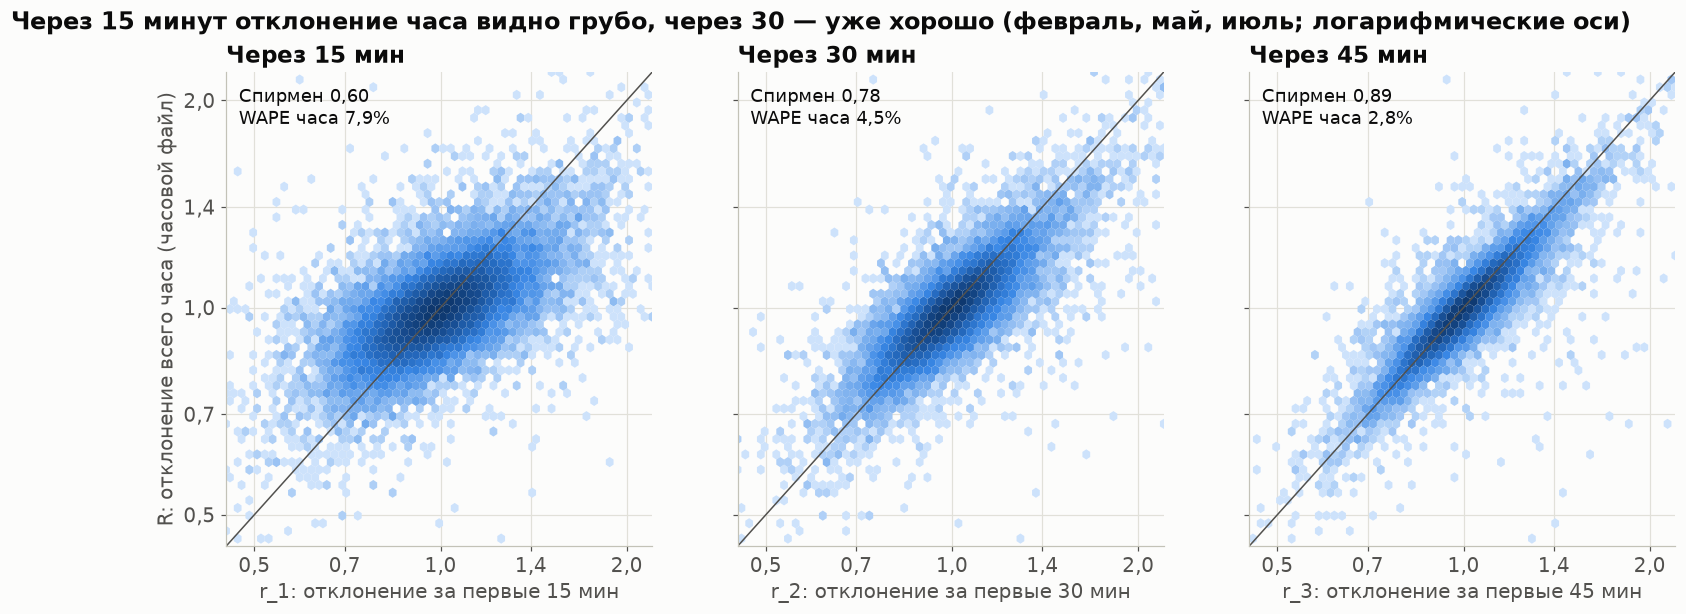

WAPE часа: норма b4 — 7,0%, «b × уровень × r(t)» — 6,0%, модель t+1 (май, июль) — 5,2%; экстраполяция через 15 / 30 / 45 мин — 7,9% / 4,5% / 2,8%; через 60 мин (весь час по 15-минутным, после s_v) — 1,2%: это расхождение источников, ниже не опуститься.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.6), sharey=True)
ticks = [0.5, 0.7, 1, 1.4, 2]
lim = np.log([0.45, 2.2])
for ax, k in zip(axes, (1, 2, 3)):
    x, y = np.log(sel[f"r{k}"].clip(0.3, 3)), np.log(sel.R.clip(0.3, 3))
    ax.hexbin(x, y, gridsize=55, extent=(*lim, *lim), bins="log", cmap=eda.blue_cmap(), mincnt=1, linewidths=0)
    ax.plot(lim, lim, color=eda.INK2, linewidth=1)
    f = fc[(fc.period == "фев + май + июль") & (fc.minute == 15 * k)].iloc[0]
    ax.text(0.03, 0.97, f"Спирмен {num(f.spearman, 2)}\nWAPE часа {pp(f.wape)}", transform=ax.transAxes, va="top",
            fontsize=12, color=eda.INK)
    ax.set_xticks(np.log(ticks), [num(t, 1) for t in ticks])
    ax.set_yticks(np.log(ticks), [num(t, 1) for t in ticks])
    ax.set_xlim(*lim)
    ax.set_ylim(*lim)
    ax.set_xlabel(f"r_{k}: отклонение за первые {15 * k} мин")
    ax.set_title(f"Через {15 * k} мин", loc="left")
axes[0].set_ylabel("R: отклонение всего часа (часовой файл)")
fig.suptitle("Через 15 минут отклонение часа видно грубо, через 30 — уже хорошо (февраль, май, июль; логарифмические оси)",
             x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "spb_16_partial_corr")
plt.show()

g = lambda m, p="фев + май + июль": fc[(fc.period == p) & (fc.minute == m) & fc.label.str.contains(":")]
best0 = fc[(fc.period == "фев + май + июль") & (fc.label == "минута 0: модель t+1 (q50)")].iloc[0]
print(f"WAPE часа: норма b4 — {pp(fc[(fc.period == 'фев + май + июль') & (fc.label == 'минута 0: норма b4')].wape.iloc[0])}, "
      f"«b × уровень × r(t)» — {pp(fc[(fc.period == 'фев + май + июль') & (fc.label == 'минута 0: b × уровень × r(t)')].wape.iloc[0])}, "
      f"модель t+1 (май, июль) — {pp(best0.wape)}; экстраполяция через 15 / 30 / 45 мин — "
      + " / ".join(pp(g(m).wape.iloc[0]) for m in (15, 30, 45)) + f"; через 60 мин (весь час по 15-минутным, после s_v) — "
      f"{pp(g(60).wape.iloc[0])}: это расхождение источников, ниже не опуститься.")

### Детектор: пороги и точность

c_k выбран по максимуму F1 на феврале + мае + июле — правило зафиксировано до просмотра сентября.
«precision ≥ 0,7» — только для информации.

In [9]:
display(res.c_select.round(3))
display(res.snapshot.round(3))
display(res.lomo.round(3))
print("По месяцам отбора (подбор на двух, проверка на третьем) F1 на 15 / 30 / 45 мин: " + "; ".join(
    f"{m} " + " / ".join(num(x, 2) for x in g.f1) for m, g in res.lomo.groupby("test_month", sort=False)) + ".")

,k,minute,c_f1,f1,precision,recall,c_prec70,precision_prec70,recall_prec70
0,1,15,1.40,0.384,0.346,0.430,NaN,NaN,NaN
1,2,30,1.10,0.545,0.491,0.611,1.8,0.708,0.217
2,3,45,1.05,0.690,0.662,0.721,1.1,0.700,0.671


,period,k,minute,c,alarms,anomalies,tp,precision,recall,f1
0,фев + май + июль,1,15,1.40,2677,2157,927,0.346,0.430,0.384
1,фев + май + июль,2,30,1.10,2680,2157,1317,0.491,0.611,0.545
2,фев + май + июль,3,45,1.05,2348,2157,1555,0.662,0.721,0.690
3,сентябрь,1,15,1.40,1918,2389,1397,0.728,0.585,0.649
4,сентябрь,2,30,1.10,2260,2389,1847,0.817,0.773,0.795
5,сентябрь,3,45,1.05,2344,2389,2038,0.869,0.853,0.861


,test_month,k,minute,c,f1,precision,recall
0,февраль,1,15,1.30,0.358,0.293,0.459
1,февраль,2,30,1.05,0.512,0.438,0.618
2,февраль,3,45,1.05,0.669,0.632,0.710
3,май,1,15,1.30,0.399,0.326,0.514
4,май,2,30,1.05,0.564,0.481,0.682
5,май,3,45,1.05,0.706,0.668,0.748
6,июль,1,15,1.40,0.376,0.357,0.398
7,июль,2,30,1.20,0.526,0.554,0.501
8,июль,3,45,1.00,0.684,0.617,0.766


По месяцам отбора (подбор на двух, проверка на третьем) F1 на 15 / 30 / 45 мин: февраль 0,36 / 0,51 / 0,67; май 0,40 / 0,56 / 0,71; июль 0,38 / 0,53 / 0,68.


### Через сколько минут видна аномалия

Детектор идёт по ходу часа: первая тревога на 15, 30 или 45 мин; на 60-й минуте — весь час по 15-минутным данным.
По часовым данным аномалия часа известна только в конце часа, на 60-й минуте.
Для сравнения — правило «прошлый час уже аномален», доступное на минуте 0.

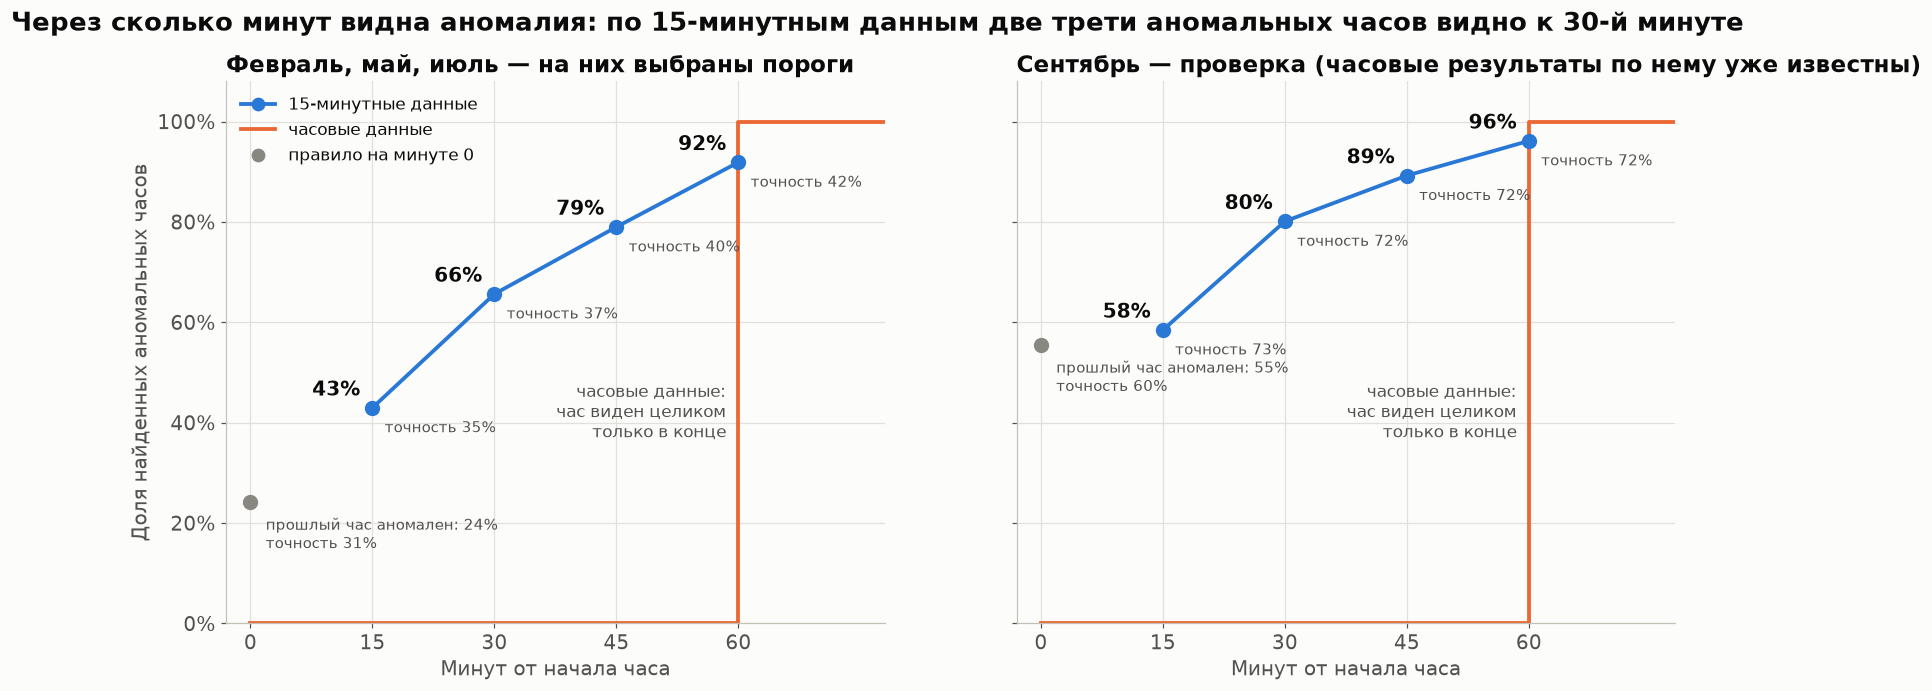

Фев + май + июль: к 15 / 30 / 45 / 60 мин найдено 43% / 66% / 79% / 92% из 2 157 аномальных часов; точность тревог 35% / 37% / 40% / 42%; ложных тревог 1,5 на вестибюль в сутки; медиана — 30 мин. Сентябрь: 58% / 80% / 89% / 96%, точность 73% / 72% / 72% / 72% (аномальных часов 20% — ступенька уровня).


In [10]:
det, m0 = res.detection, res.minute0
fig, axes = plt.subplots(1, 2, figsize=(17, 6.4), sharey=True)
titles = {"фев + май + июль": "Февраль, май, июль — на них выбраны пороги",
          "сентябрь": "Сентябрь — проверка (часовые результаты по нему уже известны)"}
for ax, (period, title) in zip(axes, titles.items()):
    d = det[det.period == period]
    z = m0[m0.period == period].iloc[0]
    ax.step([0, 60, 60, 78], [0, 0, 1, 1], where="post", color=ORANGE, linewidth=2.5)
    ax.annotate("часовые данные:\nчас виден целиком\nтолько в конце", (60, 0.42), xytext=(-8, 0),
                textcoords="offset points", ha="right", va="center", color=eda.INK2, fontsize=11)
    ax.plot(d.minute, d.recall, color=BLUE, marker="o", markersize=9, linewidth=2.5)
    for r in d.itertuples():
        ax.annotate(f"{pp(r.recall, 0)}", (r.minute, r.recall), xytext=(-8, 8), textcoords="offset points", ha="right",
                    fontsize=13, fontweight="bold", color=eda.INK)
        ax.annotate(f"точность {pp(r.precision, 0)}", (r.minute, r.recall), xytext=(8, -16), textcoords="offset points",
                    ha="left", fontsize=10, color=eda.INK2)
    ax.plot([0], [z.recall], marker="o", markersize=9, color=eda.MUTED, linestyle="none")
    ax.annotate(f"прошлый час аномален: {pp(z.recall, 0)}\nточность {pp(z.precision, 0)}", (0, z.recall), xytext=(10, -30),
                textcoords="offset points", fontsize=10, color=eda.INK2)
    ax.set_xticks([0, 15, 30, 45, 60])
    ax.set_xlim(-3, 78)
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(PCT)
    ax.set_xlabel("Минут от начала часа")
    ax.set_title(title, loc="left")
axes[0].set_ylabel("Доля найденных аномальных часов")
axes[0].legend(handles=[Line2D([], [], color=BLUE, marker="o", linewidth=2.5, label="15-минутные данные"),
                        Line2D([], [], color=ORANGE, linewidth=2.5, label="часовые данные"),
                        Line2D([], [], color=eda.MUTED, marker="o", linestyle="none", label="правило на минуте 0")],
               loc="upper left")
fig.suptitle("Через сколько минут видна аномалия: по 15-минутным данным две трети аномальных часов видно к 30-й минуте",
             x=0.01, ha="left", fontsize=17, fontweight="bold")
eda.save(fig, "spb_16_detection_time")
plt.show()

a = det[det.period == "фев + май + июль"].set_index("minute")
b = det[det.period == "сентябрь"].set_index("minute")
print(f"Фев + май + июль: к 15 / 30 / 45 / 60 мин найдено " + " / ".join(pp(a.recall[m], 0) for m in I.MINUTES)
      + f" из {num(a.anomalies.iloc[0])} аномальных часов; точность тревог " + " / ".join(pp(a.precision[m], 0) for m in I.MINUTES)
      + f"; ложных тревог {num(a.false_per_vest_day[60], 1)} на вестибюль в сутки; медиана — {num(a.median_detect_min.iloc[0])} мин. "
      f"Сентябрь: " + " / ".join(pp(b.recall[m], 0) for m in I.MINUTES) + ", точность "
      + " / ".join(pp(b.precision[m], 0) for m in I.MINUTES) + f" (аномальных часов {pp(sep.anom.mean(), 0)} — ступенька уровня).")

In [11]:
sl = res.slices[res.slices.period == "фев + май + июль"]
display(sl.drop(columns="period").round(3))
spec = res.special
display(spec.round(3))
display(res.variant_b.round(3))

,slice,key,rows,anomalies,anomaly_rate,precision_early,median_detect_min,recall_15,recall_30,recall_45,recall_60
0,направление,всплеск,14802,1224,0.083,0.416,30.0,0.475,0.703,0.825,0.949
1,направление,провал,17341,933,0.054,0.370,30.0,0.370,0.596,0.744,0.880
2,период суток,06 ч,1747,65,0.037,0.137,15.0,0.538,0.769,0.862,0.985
3,период суток,вечер 16–19,6991,454,0.065,0.429,30.0,0.434,0.685,0.837,0.971
4,период суток,день 10–15,10484,523,0.050,0.444,30.0,0.346,0.608,0.784,0.952
5,период суток,поздно 20–00,7720,667,0.086,0.494,30.0,0.460,0.667,0.771,0.865
6,период суток,утро 07–09,5201,448,0.086,0.322,30.0,0.462,0.652,0.768,0.897
7,группа,Прочие,8472,646,0.076,0.425,30.0,0.395,0.611,0.776,0.927
8,группа,Спальные конечные,12373,839,0.068,0.390,30.0,0.465,0.683,0.796,0.902
9,группа,Центр и вокзалы,11298,672,0.059,0.378,30.0,0.420,0.667,0.796,0.932


,sday,day_type,rows,anomalies,found_15,found_30,found_45,wape_r1,wape_r2,wape_f_level_r
0,2026-02-23,праздник,420,51,0.392,0.608,0.765,0.102,0.059,0.095
1,2026-05-01,праздник,421,142,0.634,0.803,0.915,0.103,0.060,0.096
2,2026-05-09,праздник,413,156,0.647,0.821,0.904,0.120,0.068,0.158
3,2026-05-11,праздник,421,121,0.686,0.785,0.893,0.097,0.057,0.100
4,2026-05-27,рабочий,423,15,0.333,0.600,0.800,0.073,0.044,0.060
5,2026-05-29,рабочий,424,20,0.350,0.450,0.700,0.084,0.052,0.064
6,2026-09-01,рабочий,422,150,0.620,0.900,0.953,0.070,0.037,0.089


,period,variant,k,minute,c,alarms,anomalies,tp,precision,recall,f1
0,фев + май + июль,"B: истина и сигнал по 15-минутным, без поправки",1,15,1.40,2774,2473,1127,0.406,0.456,0.430
1,фев + май + июль,"B: истина и сигнал по 15-минутным, без поправки",2,30,1.10,2758,2473,1577,0.572,0.638,0.603
2,фев + май + июль,"B: истина и сигнал по 15-минутным, без поправки",3,45,1.05,2440,2473,1906,0.781,0.771,0.776
3,сентябрь,"B: истина и сигнал по 15-минутным, без поправки",1,15,1.40,2085,2661,1591,0.763,0.598,0.670
4,сентябрь,"B: истина и сигнал по 15-минутным, без поправки",2,30,1.10,2487,2661,2111,0.849,0.793,0.820
5,сентябрь,"B: истина и сигнал по 15-минутным, без поправки",3,45,1.05,2566,2661,2332,0.909,0.876,0.892


## Итог

Сводка и решения — `docs/intrahour_findings.md`; таблицы — `reports/intrahour/`; профиль для симулятора —
`data/reference/intrahour_profile.csv`.